In [ ]:
import os
import math
import random
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix
)

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

In [ ]:
SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

DEVICE: cpu


In [ ]:
FILE_PATH = "final_with_weather_data_both_stations.csv"

TARGET_COLS = ["y_14d", "y_90d"]
ID_COLS = ["№ ТС", "День отправки"]

BATCH_SIZE = 512
LR = 7e-4
WEIGHT_DECAY = 1e-5
EPOCHS = 35
PATIENCE = 6

# варианты:
# "pos_weight"
# "sampler"
# "both"
IMBALANCE_MODE = "both"

# multitask оставляем True
MULTITASK = True

print("IMBALANCE_MODE:", IMBALANCE_MODE)
print("MULTITASK:", MULTITASK)

IMBALANCE_MODE: both
MULTITASK: True


In [ ]:
df = pd.read_csv("my_data.csv")

print("Shape:", df.shape)
display(df.head())

Shape: (761294, 25)


,Ст. отправления,Ст. назначения,Вес(т) факт,Расстояние(км),Стр. отправления,Стр. назначения,Замена запчастей,Вид ремонта,Дорога ремонта,Депо ремонта,...,Надрессорная балка(заменено),Колесная пара(заменено),Температура,Скорость ветра,Погода,count_shipment_7d,count_shipment_30d,count_shipment_90d,y_14d,y_90d
0,ДЯГИЛЕВО,ЗЕЛЕЦИНО,0.000,562.0,РОССИЯ,РОССИЯ,X,1.0,1.0,1.0,...,0.0,1.0,19.8,3.1,солнце,24470,24576,24581,1,1
1,КРЯЖ,ПРОТОКА,60.058,1664.0,РОССИЯ,РОССИЯ,,0.0,0.0,0.0,...,0.0,0.0,14.8,2.9,солнце,20141,20234,20239,0,0
2,НОВОРОССИЙСК (ЭКСП.),КРАСНОДАР 1,0.000,135.0,"ВИРГИН.ОСТРОВА, БРИТ",РОССИЯ,X,3.0,3.0,3.0,...,0.0,3.0,4.2,2.8,ветер,18298,18393,18398,1,1
3,КУЗНЕЧЕВСКИЙ (ЭКСП.),ОСЕНЦЫ,0.000,1684.0,НИДЕРЛАНДЫ,РОССИЯ,X,0.0,0.0,0.0,...,2.0,0.0,1.0,4.9,дождь,20141,20234,20239,1,1
4,ТАТЬЯНКА,ВЫСОЦК (ЭКСП.),65.990,2381.0,РОССИЯ,ОБЪЕДИН.АРАБ.ЭМИРАТЫ,X,4.0,4.0,4.0,...,0.0,4.0,-0.7,4.4,ветер,14184,14273,14278,1,1


In [ ]:
for col in TARGET_COLS:
    if col not in df.columns:
        raise ValueError(f"Column {col} not found")

for col in TARGET_COLS:
    df = df[df[col].notna()].copy()

for col in TARGET_COLS:
    df[col] = pd.to_numeric(df[col], errors="coerce").fillna(0).astype(int)

df = df.dropna(how="all").reset_index(drop=True)

print("Clean shape:", df.shape)
print(df[TARGET_COLS].mean())

Clean shape: (761294, 25)
y_14d    0.496030
y_90d    0.460478
dtype: float64


In [ ]:
all_feature_cols = [c for c in df.columns if c not in ID_COLS + TARGET_COLS]

context_keywords = [
    "отправ", "назнач", "station", "route", "маршрут", "стр.", "станц",
    "город", "country", "страна", "weather", "ветра", "температур",
    "дожд", "снег", "ветер", "wind", "rain", "snow",
    "train_id", "composition", "month", "месяц", "погод"
]

wagon_keywords = [
    "вагон", "wagon", "repair", "ремонт", "неисправ", "пробег", "distance",
    "shipment", "рейс", "age", "возраст", "build", "построй",
    "count_", "total_", "days_", "last_", "failure",
    "nrp", "окончание", "замен", "колес", "рама", "балка"
]

def normalize_col_name(c):
    return str(c).strip().lower()

wagon_cols = []
context_cols = []

for col in all_feature_cols:
    c = normalize_col_name(col)
    is_context = any(k in c for k in context_keywords)
    is_wagon = any(k in c for k in wagon_keywords)

    if is_context and not is_wagon:
        context_cols.append(col)
    elif is_wagon and not is_context:
        wagon_cols.append(col)
    else:
        wagon_cols.append(col)

if len(context_cols) == 0:
    context_cols = [c for c in all_feature_cols if any(k in normalize_col_name(c) for k in ["отправ", "назнач", "стр.", "станц"])]
    wagon_cols = [c for c in all_feature_cols if c not in context_cols]

print("wagon_cols:", len(wagon_cols))
print("context_cols:", len(context_cols))

print("\nWAGON sample:")
print(wagon_cols[:20])

print("\nCONTEXT sample:")
print(context_cols[:20])

wagon_cols: 16
context_cols: 7

WAGON sample:
['Вес(т) факт', 'Расстояние(км)', 'Замена запчастей', 'Вид ремонта', 'Дорога ремонта', 'Депо ремонта', 'Дней в ремонте', 'Коды неисправностей', 'Неисправности', 'Год постройки', 'Боковая рама(заменено)', 'Надрессорная балка(заменено)', 'Колесная пара(заменено)', 'count_shipment_7d', 'count_shipment_30d', 'count_shipment_90d']

CONTEXT sample:
['Ст. отправления', 'Ст. назначения', 'Стр. отправления', 'Стр. назначения', 'Температура', 'Скорость ветра', 'Погода']


In [ ]:
train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    random_state=SEED,
    stratify=df["y_14d"]
)

train_df, valid_df = train_test_split(
    train_df,
    test_size=0.2,
    random_state=SEED,
    stratify=train_df["y_14d"]
)

train_df = train_df.reset_index(drop=True)
valid_df = valid_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print("train:", train_df.shape)
print("valid:", valid_df.shape)
print("test :", test_df.shape)

train: (487228, 25)
valid: (121807, 25)
test : (152259, 25)


In [ ]:
def split_cat_num(frame, cols):
    cat_cols = []
    num_cols = []

    for col in cols:
        if frame[col].dtype == "object":
            cat_cols.append(col)
        else:
            num_cols.append(col)

    return cat_cols, num_cols

wagon_cat_cols, wagon_num_cols = split_cat_num(df, wagon_cols)
context_cat_cols, context_num_cols = split_cat_num(df, context_cols)

print("wagon_cat_cols:", len(wagon_cat_cols))
print("wagon_num_cols:", len(wagon_num_cols))
print("context_cat_cols:", len(context_cat_cols))
print("context_num_cols:", len(context_num_cols))

wagon_cat_cols: 1
wagon_num_cols: 15
context_cat_cols: 5
context_num_cols: 2


In [ ]:
class CategoryEncoder:
    def __init__(self):
        self.maps = {}
        self.cardinalities = {}

    def fit(self, df, cat_cols):
        for col in cat_cols:
            values = df[col].fillna("__MISSING__").astype(str).unique().tolist()
            vocab = {"__UNK__": 0}
            for i, v in enumerate(sorted(values), start=1):
                vocab[v] = i
            self.maps[col] = vocab
            self.cardinalities[col] = len(vocab)

    def transform(self, df, cat_cols):
        out = pd.DataFrame(index=df.index)
        for col in cat_cols:
            vocab = self.maps[col]
            out[col] = (
                df[col]
                .fillna("__MISSING__")
                .astype(str)
                .map(lambda x: vocab.get(x, 0))
                .astype("int64")
            )
        return out

In [ ]:
class NumericScaler:
    def __init__(self):
        self.cols = None
        self.means = None
        self.stds = None

    def fit(self, df, cols):
        self.cols = cols
        x = df[cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)
        self.means = x.mean()
        self.stds = x.std().replace(0, 1.0)

    def transform(self, df):
        if not self.cols:
            return pd.DataFrame(index=df.index)

        x = df[self.cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)
        x = (x - self.means) / self.stds
        return x.astype("float32")

In [ ]:
wagon_cat_encoder = CategoryEncoder()
context_cat_encoder = CategoryEncoder()

wagon_cat_encoder.fit(train_df, wagon_cat_cols)
context_cat_encoder.fit(train_df, context_cat_cols)

wagon_num_scaler = NumericScaler()
context_num_scaler = NumericScaler()

wagon_num_scaler.fit(train_df, wagon_num_cols)
context_num_scaler.fit(train_df, context_num_cols)

In [ ]:
def build_processed_split(df_part):
    wagon_cat = wagon_cat_encoder.transform(df_part, wagon_cat_cols) if len(wagon_cat_cols) > 0 else pd.DataFrame(index=df_part.index)
    context_cat = context_cat_encoder.transform(df_part, context_cat_cols) if len(context_cat_cols) > 0 else pd.DataFrame(index=df_part.index)

    wagon_num = wagon_num_scaler.transform(df_part) if len(wagon_num_cols) > 0 else pd.DataFrame(index=df_part.index)
    context_num = context_num_scaler.transform(df_part) if len(context_num_cols) > 0 else pd.DataFrame(index=df_part.index)

    y = df_part[TARGET_COLS].astype("float32").copy()

    return {
        "wagon_cat": wagon_cat,
        "wagon_num": wagon_num,
        "context_cat": context_cat,
        "context_num": context_num,
        "y": y
    }

train_data = build_processed_split(train_df)
valid_data = build_processed_split(valid_df)
test_data = build_processed_split(test_df)

for k, v in train_data.items():
    print(k, v.shape)

wagon_cat (487228, 1)
wagon_num (487228, 15)
context_cat (487228, 5)
context_num (487228, 2)
y (487228, 2)


In [ ]:
class TwoTowerDataset(Dataset):
    def __init__(self, data_dict):
        n = len(data_dict["y"])

        if data_dict["wagon_cat"].shape[1] > 0:
            self.wagon_cat = torch.tensor(data_dict["wagon_cat"].values, dtype=torch.long)
        else:
            self.wagon_cat = torch.empty((n, 0), dtype=torch.long)

        if data_dict["wagon_num"].shape[1] > 0:
            self.wagon_num = torch.tensor(data_dict["wagon_num"].values, dtype=torch.float32)
        else:
            self.wagon_num = torch.empty((n, 0), dtype=torch.float32)

        if data_dict["context_cat"].shape[1] > 0:
            self.context_cat = torch.tensor(data_dict["context_cat"].values, dtype=torch.long)
        else:
            self.context_cat = torch.empty((n, 0), dtype=torch.long)

        if data_dict["context_num"].shape[1] > 0:
            self.context_num = torch.tensor(data_dict["context_num"].values, dtype=torch.float32)
        else:
            self.context_num = torch.empty((n, 0), dtype=torch.float32)

        self.y = torch.tensor(data_dict["y"].values, dtype=torch.float32)
        self.n = n

    def __len__(self):
        return self.n

    def __getitem__(self, idx):
        return {
            "wagon_cat": self.wagon_cat[idx],
            "wagon_num": self.wagon_num[idx],
            "context_cat": self.context_cat[idx],
            "context_num": self.context_num[idx],
            "y": self.y[idx]
        }

train_ds = TwoTowerDataset(train_data)
valid_ds = TwoTowerDataset(valid_data)
test_ds = TwoTowerDataset(test_data)

In [ ]:
train_y14 = train_data["y"]["y_14d"].values.astype(int)

class_counts = np.bincount(train_y14)
class_weights = 1.0 / class_counts
sample_weights = class_weights[train_y14]

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True
)

if IMBALANCE_MODE in ["sampler", "both"]:
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler)
else:
    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)

valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

print("class_counts:", class_counts)
print("class_weights:", class_weights)

class_counts: [245548 241680]
class_weights: [4.07252350e-06 4.13770275e-06]


In [ ]:
def emb_dim(cardinality):
    return min(64, max(4, int(math.sqrt(cardinality)) + 1))

class CategoricalEmbeddingBlock(nn.Module):
    def __init__(self, cardinalities):
        super().__init__()
        self.num_features = len(cardinalities)
        self.emb_layers = nn.ModuleList([
            nn.Embedding(card, emb_dim(card))
            for card in cardinalities
        ])
        self.output_dim = sum(emb_dim(card) for card in cardinalities)

    def forward(self, x):
        if self.num_features == 0:
            return None

        embs = []
        for i, emb in enumerate(self.emb_layers):
            embs.append(emb(x[:, i]))
        return torch.cat(embs, dim=1)

In [ ]:
class Tower(nn.Module):
    def __init__(self, cat_cardinalities, num_features, tower_hidden=(256, 128), dropout=0.25):
        super().__init__()

        self.has_cat = len(cat_cardinalities) > 0
        self.has_num = num_features > 0

        if self.has_cat:
            self.cat_block = CategoricalEmbeddingBlock(cat_cardinalities)
            cat_dim = self.cat_block.output_dim
        else:
            cat_dim = 0

        if self.has_num:
            self.num_bn = nn.BatchNorm1d(num_features)
            num_dim = num_features
        else:
            num_dim = 0

        input_dim = cat_dim + num_dim
        if input_dim == 0:
            raise ValueError("Tower has no input features")

        layers = []
        prev = input_dim
        for h in tower_hidden:
            layers.extend([
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev = h

        self.mlp = nn.Sequential(*layers)
        self.output_dim = prev

    def forward(self, x_cat, x_num):
        parts = []

        if self.has_cat:
            parts.append(self.cat_block(x_cat))

        if self.has_num:
            parts.append(self.num_bn(x_num))

        x = torch.cat(parts, dim=1)
        return self.mlp(x)


class TwoTowerNetV2(nn.Module):
    def __init__(
        self,
        wagon_cat_cardinalities,
        wagon_num_features,
        context_cat_cardinalities,
        context_num_features,
        wagon_hidden=(256, 128),
        context_hidden=(128, 64),
        fusion_hidden=(256, 128, 64),
        dropout=0.25
    ):
        super().__init__()

        self.wagon_tower = Tower(
            wagon_cat_cardinalities,
            wagon_num_features,
            tower_hidden=wagon_hidden,
            dropout=dropout
        )

        self.context_tower = Tower(
            context_cat_cardinalities,
            context_num_features,
            tower_hidden=context_hidden,
            dropout=dropout
        )

        # усиленный fusion:
        # z_w, z_c, |z_w-z_c|, z_w*z_c
        z_dim = self.wagon_tower.output_dim
        c_dim = self.context_tower.output_dim

        if z_dim != c_dim:
            common_dim = min(z_dim, c_dim)
            self.align_w = nn.Linear(z_dim, common_dim)
            self.align_c = nn.Linear(c_dim, common_dim)
            fusion_input_dim = common_dim * 4
            self.final_w_dim = common_dim
            self.final_c_dim = common_dim
        else:
            self.align_w = None
            self.align_c = None
            fusion_input_dim = z_dim * 4
            self.final_w_dim = z_dim
            self.final_c_dim = c_dim

        layers = []
        prev = fusion_input_dim
        for h in fusion_hidden:
            layers.extend([
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev = h

        self.fusion = nn.Sequential(*layers)

        self.head_14 = nn.Linear(prev, 1)
        self.head_90 = nn.Linear(prev, 1)

    def forward(self, wagon_cat, wagon_num, context_cat, context_num):
        z_w = self.wagon_tower(wagon_cat, wagon_num)
        z_c = self.context_tower(context_cat, context_num)

        if self.align_w is not None:
            z_w = self.align_w(z_w)
            z_c = self.align_c(z_c)

        z_abs = torch.abs(z_w - z_c)
        z_mul = z_w * z_c

        z = torch.cat([z_w, z_c, z_abs, z_mul], dim=1)
        z = self.fusion(z)

        logit_14 = self.head_14(z)
        logit_90 = self.head_90(z)

        return logit_14, logit_90

In [ ]:
wagon_cat_cardinalities = [wagon_cat_encoder.cardinalities[c] for c in wagon_cat_cols]
context_cat_cardinalities = [context_cat_encoder.cardinalities[c] for c in context_cat_cols]

wagon_num_features = len(wagon_num_cols)
context_num_features = len(context_num_cols)

model = TwoTowerNetV2(
    wagon_cat_cardinalities=wagon_cat_cardinalities,
    wagon_num_features=wagon_num_features,
    context_cat_cardinalities=context_cat_cardinalities,
    context_num_features=context_num_features,
    wagon_hidden=(256, 128),
    context_hidden=(128, 64),
    fusion_hidden=(256, 128, 64),
    dropout=0.20
).to(DEVICE)

print(model)

TwoTowerNetV2(
  (wagon_tower): Tower(
    (cat_block): CategoricalEmbeddingBlock(
      (emb_layers): ModuleList(
        (0): Embedding(3, 4)
      )
    )
    (num_bn): BatchNorm1d(15, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (mlp): Sequential(
      (0): Linear(in_features=19, out_features=256, bias=True)
      (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): Dropout(p=0.2, inplace=False)
      (4): Linear(in_features=256, out_features=128, bias=True)
      (5): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): Dropout(p=0.2, inplace=False)
    )
  )
  (context_tower): Tower(
    (cat_block): CategoricalEmbeddingBlock(
      (emb_layers): ModuleList(
        (0): Embedding(865, 30)
        (1): Embedding(829, 29)
        (2): Embedding(42, 7)
        (3): Embedding(38, 7)
        (4): Embedding(5, 4)
      )
    )
    (num_bn): Bat

In [ ]:
train_y = train_data["y"]

def compute_pos_weight(y_series):
    pos = y_series.sum()
    neg = len(y_series) - pos
    if pos == 0:
        return 1.0
    return float(neg / pos)

pos_weight_14 = compute_pos_weight(train_y["y_14d"])
pos_weight_90 = compute_pos_weight(train_y["y_90d"])

print("pos_weight_14:", pos_weight_14)
print("pos_weight_90:", pos_weight_90)

if IMBALANCE_MODE in ["pos_weight", "both"]:
    criterion_14 = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight_14], device=DEVICE))
    criterion_90 = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight_90], device=DEVICE))
else:
    criterion_14 = nn.BCEWithLogitsLoss()
    criterion_90 = nn.BCEWithLogitsLoss()

optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

pos_weight_14: 1.0160046815872192
pos_weight_90: 1.171422004699707


In [ ]:
def move_batch_to_device(batch):
    return {k: v.to(DEVICE) for k, v in batch.items()}


def train_one_epoch(model, loader, optimizer, criterion_14, criterion_90):
    model.train()
    losses = []

    for batch in loader:
        batch = move_batch_to_device(batch)

        optimizer.zero_grad()

        logit_14, logit_90 = model(
            batch["wagon_cat"],
            batch["wagon_num"],
            batch["context_cat"],
            batch["context_num"]
        )

        y14 = batch["y"][:, 0:1]
        y90 = batch["y"][:, 1:2]

        loss14 = criterion_14(logit_14, y14)
        loss90 = criterion_90(logit_90, y90)
        loss = loss14 + loss90

        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return float(np.mean(losses))


@torch.no_grad()
def predict_loader(model, loader):
    model.eval()

    p14_all, p90_all = [], []
    y14_all, y90_all = [], []

    for batch in loader:
        batch = move_batch_to_device(batch)

        logit_14, logit_90 = model(
            batch["wagon_cat"],
            batch["wagon_num"],
            batch["context_cat"],
            batch["context_num"]
        )

        p14 = torch.sigmoid(logit_14).cpu().numpy().ravel()
        p90 = torch.sigmoid(logit_90).cpu().numpy().ravel()

        y14 = batch["y"][:, 0].cpu().numpy().ravel()
        y90 = batch["y"][:, 1].cpu().numpy().ravel()

        p14_all.extend(p14.tolist())
        p90_all.extend(p90.tolist())
        y14_all.extend(y14.tolist())
        y90_all.extend(y90.tolist())

    return {
        "y14": np.array(y14_all).astype(int),
        "p14": np.array(p14_all),
        "y90": np.array(y90_all).astype(int),
        "p90": np.array(p90_all),
    }


def evaluate_predictions(y_true, p, threshold=0.5):
    pred = (p >= threshold).astype(int)

    metrics = {
        "roc_auc": roc_auc_score(y_true, p),
        "pr_auc": average_precision_score(y_true, p),
        "f1": f1_score(y_true, pred, zero_division=0)
    }
    return metrics, pred

In [ ]:
best_score = -1
best_state = None
patience_counter = 0
history = []

for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion_14, criterion_90)

    valid_pred = predict_loader(model, valid_loader)

    valid_m14, _ = evaluate_predictions(valid_pred["y14"], valid_pred["p14"])
    valid_m90, _ = evaluate_predictions(valid_pred["y90"], valid_pred["p90"])

    # ориентируемся в первую очередь на PR-AUC
    score = valid_m14["pr_auc"] + valid_m90["pr_auc"]

    history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "valid_roc_auc_14": valid_m14["roc_auc"],
        "valid_pr_auc_14": valid_m14["pr_auc"],
        "valid_f1_14": valid_m14["f1"],
        "valid_roc_auc_90": valid_m90["roc_auc"],
        "valid_pr_auc_90": valid_m90["pr_auc"],
        "valid_f1_90": valid_m90["f1"]
    })

    print(
        f"Epoch {epoch:02d} | "
        f"loss={train_loss:.4f} | "
        f"14d PR-AUC={valid_m14['pr_auc']:.4f} ROC-AUC={valid_m14['roc_auc']:.4f} | "
        f"90d PR-AUC={valid_m90['pr_auc']:.4f} ROC-AUC={valid_m90['roc_auc']:.4f}"
    )

    if score > best_score:
        best_score = score
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= PATIENCE:
        print(f"Early stopping at epoch {epoch}")
        break

history_df = pd.DataFrame(history)
display(history_df)

Epoch 01 | loss=1.3475 | 14d PR-AUC=0.7072 ROC-AUC=0.7178 | 90d PR-AUC=0.6772 ROC-AUC=0.7184
Epoch 02 | loss=1.2849 | 14d PR-AUC=0.7312 ROC-AUC=0.7398 | 90d PR-AUC=0.7020 ROC-AUC=0.7405
Epoch 03 | loss=1.2550 | 14d PR-AUC=0.7450 ROC-AUC=0.7532 | 90d PR-AUC=0.7161 ROC-AUC=0.7534
Epoch 04 | loss=1.2364 | 14d PR-AUC=0.7567 ROC-AUC=0.7621 | 90d PR-AUC=0.7290 ROC-AUC=0.7628
Epoch 05 | loss=1.2167 | 14d PR-AUC=0.7632 ROC-AUC=0.7684 | 90d PR-AUC=0.7359 ROC-AUC=0.7691
Epoch 06 | loss=1.2079 | 14d PR-AUC=0.7708 ROC-AUC=0.7750 | 90d PR-AUC=0.7438 ROC-AUC=0.7756
Epoch 07 | loss=1.1972 | 14d PR-AUC=0.7761 ROC-AUC=0.7794 | 90d PR-AUC=0.7487 ROC-AUC=0.7798
Epoch 08 | loss=1.1865 | 14d PR-AUC=0.7794 ROC-AUC=0.7832 | 90d PR-AUC=0.7528 ROC-AUC=0.7839
Epoch 09 | loss=1.1779 | 14d PR-AUC=0.7845 ROC-AUC=0.7886 | 90d PR-AUC=0.7581 ROC-AUC=0.7888
Epoch 10 | loss=1.1700 | 14d PR-AUC=0.7885 ROC-AUC=0.7916 | 90d PR-AUC=0.7621 ROC-AUC=0.7923
Epoch 11 | loss=1.1632 | 14d PR-AUC=0.7905 ROC-AUC=0.7944 | 90d PR-AUC

,epoch,train_loss,valid_roc_auc_14,valid_pr_auc_14,valid_f1_14,valid_roc_auc_90,valid_pr_auc_90,valid_f1_90
0,1,1.347468,0.717837,0.707190,0.654011,0.718408,0.677187,0.640086
1,2,1.284933,0.739846,0.731227,0.681422,0.740454,0.702010,0.666672
2,3,1.255022,0.753184,0.745034,0.676981,0.753406,0.716147,0.665233
3,4,1.236422,0.762125,0.756704,0.690679,0.762769,0.728954,0.676690
4,5,1.216675,0.768397,0.763219,0.693730,0.769114,0.735853,0.680919
5,6,1.207893,0.775021,0.770809,0.700909,0.775614,0.743776,0.687780
6,7,1.197169,0.779430,0.776106,0.699303,0.779810,0.748746,0.686947
7,8,1.186550,0.783151,0.779393,0.701433,0.783866,0.752844,0.689266
8,9,1.177892,0.788557,0.784546,0.707772,0.788802,0.758092,0.695247
9,10,1.170027,0.791647,0.788507,0.716225,0.792285,0.762132,0.703563


In [ ]:
model.load_state_dict(best_state)
print("Best model restored.")

Best model restored.


In [ ]:
test_pred = predict_loader(model, test_loader)

test_m14, test_cls14 = evaluate_predictions(test_pred["y14"], test_pred["p14"], threshold=0.5)
test_m90, test_cls90 = evaluate_predictions(test_pred["y90"], test_pred["p90"], threshold=0.5)

print("=== TEST y_14d | threshold=0.5 ===")
print(test_m14)
print(classification_report(test_pred["y14"], test_cls14, digits=4))

print("\n=== TEST y_90d | threshold=0.5 ===")
print(test_m90)
print(classification_report(test_pred["y90"], test_cls90, digits=4))

=== TEST y_14d | threshold=0.5 ===
{'roc_auc': np.float64(0.8362482931207769), 'pr_auc': np.float64(0.8354228791715786), 'f1': 0.7495328332675352}
              precision    recall  f1-score   support

           0     0.7551    0.7459    0.7504     76734
           1     0.7450    0.7541    0.7495     75525

    accuracy                         0.7500    152259
   macro avg     0.7500    0.7500    0.7500    152259
weighted avg     0.7501    0.7500    0.7500    152259


=== TEST y_90d | threshold=0.5 ===
{'roc_auc': np.float64(0.8369845869916702), 'pr_auc': np.float64(0.8134552265052435), 'f1': 0.7382006051499496}
              precision    recall  f1-score   support

           0     0.7872    0.7340    0.7597     82157
           1     0.7111    0.7674    0.7382     70102

    accuracy                         0.7494    152259
   macro avg     0.7492    0.7507    0.7489    152259
weighted avg     0.7522    0.7494    0.7498    152259



In [ ]:
def find_best_threshold(y_true, y_prob, metric="f1", thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.05, 0.96, 0.01)

    rows = []

    for thr in thresholds:
        y_pred = (y_prob >= thr).astype(int)

        precision = precision_score(y_true, y_pred, zero_division=0)
        recall = recall_score(y_true, y_pred, zero_division=0)
        f1 = f1_score(y_true, y_pred, zero_division=0)

        rows.append({
            "threshold": thr,
            "precision": precision,
            "recall": recall,
            "f1": f1
        })

    table = pd.DataFrame(rows)

    if metric == "f1":
        best_idx = table["f1"].idxmax()
    elif metric == "recall":
        best_idx = table["recall"].idxmax()
    elif metric == "precision":
        best_idx = table["precision"].idxmax()
    else:
        raise ValueError("metric must be one of: 'f1', 'recall', 'precision'")

    return table, table.loc[best_idx]

In [ ]:
valid_pred = predict_loader(model, valid_loader)

thr_table_14, best_thr_14 = find_best_threshold(
    y_true=valid_pred["y14"],
    y_prob=valid_pred["p14"],
    metric="f1"
)

thr_table_90, best_thr_90 = find_best_threshold(
    y_true=valid_pred["y90"],
    y_prob=valid_pred["p90"],
    metric="f1"
)

print("Best threshold for y_14d:")
display(best_thr_14)

print("Best threshold for y_90d:")
display(best_thr_90)

Best threshold for y_14d:


,37
threshold,0.420000
precision,0.702577
recall,0.838894
f1,0.764708


Best threshold for y_90d:


,39
threshold,0.440000
precision,0.680150
recall,0.830299
f1,0.747762


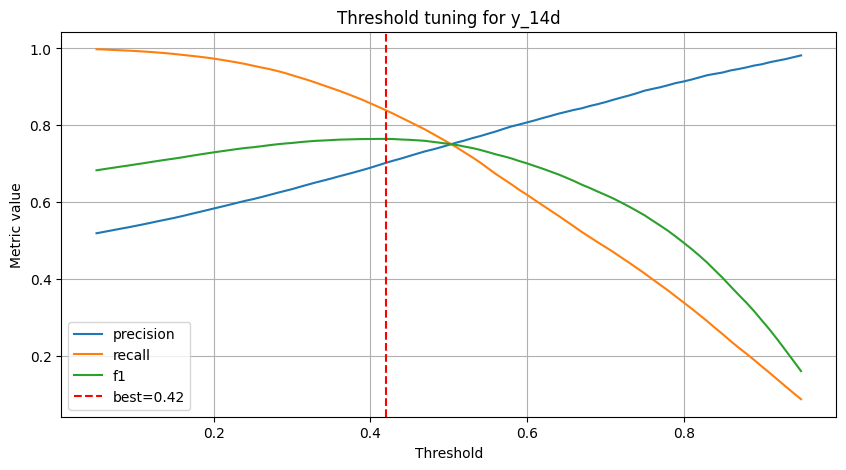

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(thr_table_14["threshold"], thr_table_14["precision"], label="precision")
plt.plot(thr_table_14["threshold"], thr_table_14["recall"], label="recall")
plt.plot(thr_table_14["threshold"], thr_table_14["f1"], label="f1")
plt.axvline(best_thr_14["threshold"], color="red", linestyle="--", label=f"best={best_thr_14['threshold']:.2f}")
plt.title("Threshold tuning for y_14d")
plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.legend()
plt.grid(True)
plt.show()

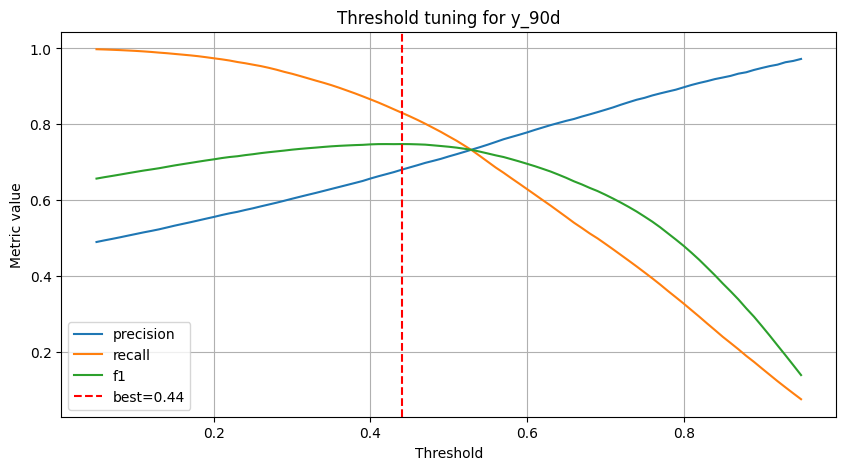

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(thr_table_90["threshold"], thr_table_90["precision"], label="precision")
plt.plot(thr_table_90["threshold"], thr_table_90["recall"], label="recall")
plt.plot(thr_table_90["threshold"], thr_table_90["f1"], label="f1")
plt.axvline(best_thr_90["threshold"], color="red", linestyle="--", label=f"best={best_thr_90['threshold']:.2f}")
plt.title("Threshold tuning for y_90d")
plt.xlabel("Threshold")
plt.ylabel("Metric value")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
best_threshold_14 = float(best_thr_14["threshold"])
best_threshold_90 = float(best_thr_90["threshold"])

test_cls14_tuned = (test_pred["p14"] >= best_threshold_14).astype(int)
test_cls90_tuned = (test_pred["p90"] >= best_threshold_90).astype(int)

print("=== TEST y_14d | tuned threshold ===")
print("threshold:", best_threshold_14)
print("ROC-AUC:", roc_auc_score(test_pred["y14"], test_pred["p14"]))
print("PR-AUC :", average_precision_score(test_pred["y14"], test_pred["p14"]))
print(classification_report(test_pred["y14"], test_cls14_tuned, digits=4))
print("Confusion matrix:")
print(confusion_matrix(test_pred["y14"], test_cls14_tuned))

print("\n=== TEST y_90d | tuned threshold ===")
print("threshold:", best_threshold_90)
print("ROC-AUC:", roc_auc_score(test_pred["y90"], test_pred["p90"]))
print("PR-AUC :", average_precision_score(test_pred["y90"], test_pred["p90"]))
print(classification_report(test_pred["y90"], test_cls90_tuned, digits=4))
print("Confusion matrix:")
print(confusion_matrix(test_pred["y90"], test_cls90_tuned))

=== TEST y_14d | tuned threshold ===
threshold: 0.42000000000000004
ROC-AUC: 0.8362482931207769
PR-AUC : 0.8354228791715786
              precision    recall  f1-score   support

           0     0.8027    0.6477    0.7169     76734
           1     0.7008    0.8382    0.7634     75525

    accuracy                         0.7422    152259
   macro avg     0.7517    0.7430    0.7401    152259
weighted avg     0.7521    0.7422    0.7399    152259

Confusion matrix:
[[49699 27035]
 [12217 63308]]

=== TEST y_90d | tuned threshold ===
threshold: 0.44000000000000006
ROC-AUC: 0.8369845869916702
PR-AUC : 0.8134552265052435
              precision    recall  f1-score   support

           0     0.8200    0.6628    0.7330     82157
           1     0.6773    0.8295    0.7457     70102

    accuracy                         0.7395    152259
   macro avg     0.7486    0.7461    0.7394    152259
weighted avg     0.7543    0.7395    0.7389    152259

Confusion matrix:
[[54450 27707]
 [11952 58150]]

In [ ]:
def choose_threshold_with_min_recall(table, min_recall=0.80):
    candidates = table[table["recall"] >= min_recall].copy()
    if len(candidates) == 0:
        return None
    return candidates.sort_values(["precision", "f1"], ascending=False).iloc[0]

recall_thr_14 = choose_threshold_with_min_recall(thr_table_14, min_recall=0.80)
recall_thr_90 = choose_threshold_with_min_recall(thr_table_90, min_recall=0.80)

print("Recall-oriented threshold for y_14d:")
display(recall_thr_14)

print("Recall-oriented threshold for y_90d:")
display(recall_thr_90)

Recall-oriented threshold for y_14d:


,40
threshold,0.450000
precision,0.720460
recall,0.809235
f1,0.762272


Recall-oriented threshold for y_90d:


,42
threshold,0.470000
precision,0.698159
recall,0.801373
f1,0.746214


In [ ]:
if recall_thr_14 is not None:
    thr14_recall = float(recall_thr_14["threshold"])
    test_cls14_recall = (test_pred["p14"] >= thr14_recall).astype(int)

    print("=== TEST y_14d | recall-oriented threshold ===")
    print("threshold:", thr14_recall)
    print(classification_report(test_pred["y14"], test_cls14_recall, digits=4))
    print(confusion_matrix(test_pred["y14"], test_cls14_recall))
else:
    print("No threshold found for y_14d with desired recall")

if recall_thr_90 is not None:
    thr90_recall = float(recall_thr_90["threshold"])
    test_cls90_recall = (test_pred["p90"] >= thr90_recall).astype(int)

    print("\n=== TEST y_90d | recall-oriented threshold ===")
    print("threshold:", thr90_recall)
    print(classification_report(test_pred["y90"], test_cls90_recall, digits=4))
    print(confusion_matrix(test_pred["y90"], test_cls90_recall))
else:
    print("No threshold found for y_90d with desired recall")

=== TEST y_14d | recall-oriented threshold ===
threshold: 0.45000000000000007
              precision    recall  f1-score   support

           0     0.7847    0.6862    0.7322     76734
           1     0.7173    0.8087    0.7603     75525

    accuracy                         0.7470    152259
   macro avg     0.7510    0.7475    0.7462    152259
weighted avg     0.7513    0.7470    0.7461    152259

[[52658 24076]
 [14446 61079]]

=== TEST y_90d | recall-oriented threshold ===
threshold: 0.4700000000000001
              precision    recall  f1-score   support

           0     0.8037    0.6992    0.7478     82157
           1     0.6941    0.7999    0.7432     70102

    accuracy                         0.7455    152259
   macro avg     0.7489    0.7495    0.7455    152259
weighted avg     0.7532    0.7455    0.7457    152259

[[57441 24716]
 [14028 56074]]


In [ ]:
# baseline values from raw train_df
baseline_numeric = {}
baseline_categorical = {}

all_model_cols = wagon_cols + context_cols

for col in all_model_cols:
    if col in train_df.columns:
        if train_df[col].dtype == "object":
            mode_val = train_df[col].fillna("__MISSING__").astype(str).mode()
            baseline_categorical[col] = mode_val.iloc[0] if len(mode_val) > 0 else "__MISSING__"
        else:
            baseline_numeric[col] = pd.to_numeric(train_df[col], errors="coerce").fillna(0).median()

print("numeric baselines:", len(baseline_numeric))
print("categorical baselines:", len(baseline_categorical))

numeric baselines: 17
categorical baselines: 6


In [ ]:
feature_groups = {
    "repair_history": [
        c for c in all_model_cols
        if any(k in c.lower() for k in ["repair", "ремонт", "неисправ", "nrp", "замен", "окончание"])
    ],
    "operational_load": [
        c for c in all_model_cols
        if any(k in c.lower() for k in ["distance", "пробег", "рейс", "shipment", "count_", "total_", "days_"])
    ],
    "weather": [
        c for c in all_model_cols
        if any(k in c.lower() for k in ["weather", "temp", "температур", "rain", "snow", "wind", "дожд", "снег", "ветер"])
    ],
    "route_station_context": [
        c for c in all_model_cols
        if any(k in c.lower() for k in ["отправ", "назнач", "station", "route", "маршрут", "стр.", "станц", "город", "страна", "country"])
    ],
    "composition_context": [
        c for c in all_model_cols
        if any(k in c.lower() for k in ["train_id", "composition", "month", "месяц"])
    ],
    "wagon_intrinsic": [
        c for c in all_model_cols
        if any(k in c.lower() for k in ["вагон", "wagon", "возраст", "age", "build", "построй", "колес", "рама", "балка"])
    ]
}

# убрать пустые группы
feature_groups = {k: v for k, v in feature_groups.items() if len(v) > 0}

feature_groups

{'repair_history': ['Замена запчастей',
  'Вид ремонта',
  'Дорога ремонта',
  'Депо ремонта',
  'Дней в ремонте',
  'Коды неисправностей',
  'Неисправности',
  'Боковая рама(заменено)',
  'Надрессорная балка(заменено)',
  'Колесная пара(заменено)'],
 'operational_load': ['count_shipment_7d',
  'count_shipment_30d',
  'count_shipment_90d'],
 'weather': ['Температура'],
 'route_station_context': ['Ст. отправления',
  'Ст. назначения',
  'Стр. отправления',
  'Стр. назначения'],
 'wagon_intrinsic': ['Год постройки',
  'Боковая рама(заменено)',
  'Надрессорная балка(заменено)',
  'Колесная пара(заменено)']}

In [ ]:
def preprocess_one_row(raw_row_df):
    # raw_row_df = DataFrame из 1 строки в исходных колонках

    wagon_cat = wagon_cat_encoder.transform(raw_row_df, wagon_cat_cols) if len(wagon_cat_cols) > 0 else pd.DataFrame(index=raw_row_df.index)
    context_cat = context_cat_encoder.transform(raw_row_df, context_cat_cols) if len(context_cat_cols) > 0 else pd.DataFrame(index=raw_row_df.index)

    wagon_num = wagon_num_scaler.transform(raw_row_df) if len(wagon_num_cols) > 0 else pd.DataFrame(index=raw_row_df.index)
    context_num = context_num_scaler.transform(raw_row_df) if len(context_num_cols) > 0 else pd.DataFrame(index=raw_row_df.index)

    n = len(raw_row_df)

    wagon_cat_tensor = torch.tensor(wagon_cat.values, dtype=torch.long) if wagon_cat.shape[1] > 0 else torch.empty((n, 0), dtype=torch.long)
    wagon_num_tensor = torch.tensor(wagon_num.values, dtype=torch.float32) if wagon_num.shape[1] > 0 else torch.empty((n, 0), dtype=torch.float32)

    context_cat_tensor = torch.tensor(context_cat.values, dtype=torch.long) if context_cat.shape[1] > 0 else torch.empty((n, 0), dtype=torch.long)
    context_num_tensor = torch.tensor(context_num.values, dtype=torch.float32) if context_num.shape[1] > 0 else torch.empty((n, 0), dtype=torch.float32)

    return {
        "wagon_cat": wagon_cat_tensor.to(DEVICE),
        "wagon_num": wagon_num_tensor.to(DEVICE),
        "context_cat": context_cat_tensor.to(DEVICE),
        "context_num": context_num_tensor.to(DEVICE),
    }

In [ ]:
@torch.no_grad()
def predict_one_row(raw_row_df):
    model.eval()

    batch = preprocess_one_row(raw_row_df)

    logit_14, logit_90 = model(
        batch["wagon_cat"],
        batch["wagon_num"],
        batch["context_cat"],
        batch["context_num"]
    )

    p14 = torch.sigmoid(logit_14).cpu().numpy().ravel()[0]
    p90 = torch.sigmoid(logit_90).cpu().numpy().ravel()[0]

    return {
        "p14": float(p14),
        "p90": float(p90)
    }

In [ ]:
def replace_feature_with_baseline(raw_row_df, feature_name):
    row = raw_row_df.copy()

    if feature_name in baseline_numeric:
        row.loc[row.index[0], feature_name] = baseline_numeric[feature_name]
    elif feature_name in baseline_categorical:
        row.loc[row.index[0], feature_name] = baseline_categorical[feature_name]
    else:
        # fallback
        if feature_name in row.columns:
            if row[feature_name].dtype == "object":
                row.loc[row.index[0], feature_name] = "__MISSING__"
            else:
                row.loc[row.index[0], feature_name] = 0

    return row

In [ ]:
def explain_one_wagon_features(raw_row_df, target="y_14d", top_k=10):
    base_pred = predict_one_row(raw_row_df)
    base_prob = base_pred["p14"] if target == "y_14d" else base_pred["p90"]

    rows = []

    for col in all_model_cols:
        if col not in raw_row_df.columns:
            continue

        modified_row = replace_feature_with_baseline(raw_row_df, col)
        new_pred = predict_one_row(modified_row)
        new_prob = new_pred["p14"] if target == "y_14d" else new_pred["p90"]

        contribution = base_prob - new_prob

        rows.append({
            "feature": col,
            "base_prob": base_prob,
            "new_prob": new_prob,
            "contribution": contribution
        })

    result = pd.DataFrame(rows).sort_values("contribution", ascending=False).reset_index(drop=True)

    return {
        "base_probability": base_prob,
        "top_positive_contributors": result.head(top_k),
        "full_table": result
    }

In [ ]:
def replace_group_with_baseline(raw_row_df, feature_list):
    row = raw_row_df.copy()

    for feature_name in feature_list:
        if feature_name not in row.columns:
            continue

        if feature_name in baseline_numeric:
            row.loc[row.index[0], feature_name] = baseline_numeric[feature_name]
        elif feature_name in baseline_categorical:
            row.loc[row.index[0], feature_name] = baseline_categorical[feature_name]
        else:
            if row[feature_name].dtype == "object":
                row.loc[row.index[0], feature_name] = "__MISSING__"
            else:
                row.loc[row.index[0], feature_name] = 0

    return row


def explain_one_wagon_groups(raw_row_df, target="y_14d"):
    base_pred = predict_one_row(raw_row_df)
    base_prob = base_pred["p14"] if target == "y_14d" else base_pred["p90"]

    rows = []

    for group_name, group_features in feature_groups.items():
        modified_row = replace_group_with_baseline(raw_row_df, group_features)
        new_pred = predict_one_row(modified_row)
        new_prob = new_pred["p14"] if target == "y_14d" else new_pred["p90"]

        contribution = base_prob - new_prob

        rows.append({
            "group": group_name,
            "base_prob": base_prob,
            "new_prob": new_prob,
            "contribution": contribution
        })

    result = pd.DataFrame(rows).sort_values("contribution", ascending=False).reset_index(drop=True)

    return {
        "base_probability": base_prob,
        "group_contributions": result
    }

In [ ]:
example_idx = 0
example_row = test_df.iloc[[example_idx]].copy()

display(example_row[["№ ТС", "День отправки", "y_14d", "y_90d"]] if all(c in example_row.columns for c in ["№ ТС", "День отправки", "y_14d", "y_90d"]) else example_row.head())

,Ст. отправления,Ст. назначения,Вес(т) факт,Расстояние(км),Стр. отправления,Стр. назначения,Замена запчастей,Вид ремонта,Дорога ремонта,Депо ремонта,...,Надрессорная балка(заменено),Колесная пара(заменено),Температура,Скорость ветра,Погода,count_shipment_7d,count_shipment_30d,count_shipment_90d,y_14d,y_90d
0,НИКЕЛЬ,НИКЕЛЬ,0.0,5.0,РОССИЯ,РОССИЯ,,0.0,0.0,0.0,...,0.0,0.0,10.3,3.4,солнце,15301,15399,15403,0,0


In [ ]:
explain_14 = explain_one_wagon_features(example_row, target="y_14d", top_k=10)

print("Base probability y_14d:", explain_14["base_probability"])
display(explain_14["top_positive_contributors"])

Base probability y_14d: 0.22044430673122406


,feature,base_prob,new_prob,contribution
0,Расстояние(км),0.220444,0.170986,0.049458
1,Температура,0.220444,0.191982,0.028462
2,count_shipment_90d,0.220444,0.202841,0.017603
3,count_shipment_7d,0.220444,0.202879,0.017566
4,count_shipment_30d,0.220444,0.208490,0.011954
5,Год постройки,0.220444,0.216276,0.004168
6,Вес(т) факт,0.220444,0.220444,0.000000
7,Дней в ремонте,0.220444,0.220444,0.000000
8,Депо ремонта,0.220444,0.220444,0.000000
9,Дорога ремонта,0.220444,0.220444,0.000000


In [ ]:
explain_90 = explain_one_wagon_features(example_row, target="y_90d", top_k=10)

print("Base probability y_90d:", explain_90["base_probability"])
display(explain_90["top_positive_contributors"])

Base probability y_90d: 0.20114238560199738


,feature,base_prob,new_prob,contribution
0,Расстояние(км),0.201142,0.148673,0.052469
1,Температура,0.201142,0.170815,0.030327
2,count_shipment_7d,0.201142,0.181938,0.019205
3,count_shipment_90d,0.201142,0.181938,0.019205
4,count_shipment_30d,0.201142,0.187926,0.013217
5,Год постройки,0.201142,0.196784,0.004358
6,Вес(т) факт,0.201142,0.201142,0.000000
7,Дней в ремонте,0.201142,0.201142,0.000000
8,Депо ремонта,0.201142,0.201142,0.000000
9,Дорога ремонта,0.201142,0.201142,0.000000


In [ ]:
group_explain_14 = explain_one_wagon_groups(example_row, target="y_14d")

print("Base probability y_14d:", group_explain_14["base_probability"])
display(group_explain_14["group_contributions"])

Base probability y_14d: 0.22044430673122406


,group,base_prob,new_prob,contribution
0,operational_load,0.220444,0.190949,0.029495
1,weather,0.220444,0.191982,0.028462
2,wagon_intrinsic,0.220444,0.216276,0.004168
3,repair_history,0.220444,0.220444,0.000000
4,route_station_context,0.220444,0.564484,-0.344039


In [ ]:
group_explain_90 = explain_one_wagon_groups(example_row, target="y_90d")

print("Base probability y_90d:", group_explain_90["base_probability"])
display(group_explain_90["group_contributions"])

Base probability y_90d: 0.20114238560199738


,group,base_prob,new_prob,contribution
0,operational_load,0.201142,0.170034,0.031108
1,weather,0.201142,0.170815,0.030327
2,wagon_intrinsic,0.201142,0.196784,0.004358
3,repair_history,0.201142,0.201142,0.000000
4,route_station_context,0.201142,0.559241,-0.358098


In [ ]:
def verbal_explanation(raw_row_df, target="y_14d", top_k=5):
    feat_exp = explain_one_wagon_features(raw_row_df, target=target, top_k=top_k)
    group_exp = explain_one_wagon_groups(raw_row_df, target=target)

    base_prob = feat_exp["base_probability"]
    top_feats = feat_exp["top_positive_contributors"]
    top_groups = group_exp["group_contributions"].head(3)

    print(f"Predicted probability of failure ({target}): {base_prob:.4f}")
    print("\nMain contributing feature groups:")
    for _, row in top_groups.iterrows():
        print(f"- {row['group']}: +{row['contribution']:.4f}")

    print("\nTop individual contributing features:")
    for _, row in top_feats.iterrows():
        print(f"- {row['feature']}: +{row['contribution']:.4f}")

verbal_explanation(example_row, target="y_14d", top_k=5)

Predicted probability of failure (y_14d): 0.2204

Main contributing feature groups:
- operational_load: +0.0295
- weather: +0.0285
- wagon_intrinsic: +0.0042

Top individual contributing features:
- Расстояние(км): +0.0495
- Температура: +0.0285
- count_shipment_90d: +0.0176
- count_shipment_7d: +0.0176
- count_shipment_30d: +0.0120


In [ ]:
SAVE_PATH = "two_tower_full_bundle.pt"

bundle = {
    "model_state_dict": model.state_dict(),

    "wagon_cat_cols": wagon_cat_cols,
    "wagon_num_cols": wagon_num_cols,
    "context_cat_cols": context_cat_cols,
    "context_num_cols": context_num_cols,

    "wagon_cat_cardinalities": wagon_cat_cardinalities,
    "context_cat_cardinalities": context_cat_cardinalities,

    "wagon_cat_maps": wagon_cat_encoder.maps,
    "context_cat_maps": context_cat_encoder.maps,

    "wagon_num_means": wagon_num_scaler.means.to_dict() if wagon_num_scaler.means is not None else {},
    "wagon_num_stds": wagon_num_scaler.stds.to_dict() if wagon_num_scaler.stds is not None else {},

    "context_num_means": context_num_scaler.means.to_dict() if context_num_scaler.means is not None else {},
    "context_num_stds": context_num_scaler.stds.to_dict() if context_num_scaler.stds is not None else {},

    "best_threshold_14": float(best_thr_14["threshold"]) if "best_thr_14" in globals() else 0.5,
    "best_threshold_90": float(best_thr_90["threshold"]) if "best_thr_90" in globals() else 0.5,
}

torch.save(bundle, SAVE_PATH)
print("Saved to:", SAVE_PATH)

Saved to: two_tower_full_bundle.pt


In [ ]:
from google.colab import files
files.download("two_tower_full_bundle.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [54]:
import json
import math
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import shap


# =========================================================
# CONFIG
# =========================================================

MODEL_PATH = "two_tower_full_bundle.pt"
DATA_PATH = "my_data_with_wagon_id.csv"
OUTPUT_PATH = "wagons_data.json"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED = 42

TARGET_COLS = ["y_14d", "y_90d"]
ID_CANDIDATES = ["wagon_id"]
DATE_CANDIDATES = ["День отправки", "date", "dispatch_date"]

# SHAP для всех вагонов
BACKGROUND_SIZE = 80
EXPLAIN_MAX_ROWS = None


# =========================================================
# UTILS
# =========================================================

def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_everything(SEED)


def safe_float(x):
    try:
        if pd.isna(x):
            return None
        return float(x)
    except Exception:
        return None


def safe_value(x):
    if pd.isna(x):
        return None
    if isinstance(x, (np.integer, int)):
        return int(x)
    if isinstance(x, (np.floating, float)):
        return float(x)
    return str(x)


def risk_level(r14, r90, thr14, thr90):
    high = (r14 >= thr14) or (r90 >= thr90)
    med = (r14 >= max(0.35, thr14 - 0.10)) or (r90 >= max(0.35, thr90 - 0.10))
    if high:
        return "High"
    if med:
        return "Medium"
    return "Low"


def first_existing(cols, frame):
    for c in cols:
        if c in frame.columns:
            return c
    return None


# =========================================================
# PREPROCESSING CLASSES
# =========================================================

class CategoryEncoder:
    def __init__(self):
        self.maps = {}
        self.cardinalities = {}

    def transform(self, df, cat_cols):
        out = pd.DataFrame(index=df.index)
        for col in cat_cols:
            vocab = self.maps[col]
            out[col] = (
                df[col]
                .fillna("__MISSING__")
                .astype(str)
                .map(lambda x: vocab.get(x, 0))
                .astype("int64")
            )
        return out


class NumericScaler:
    def __init__(self):
        self.cols = None
        self.means = None
        self.stds = None

    def transform(self, df):
        if not self.cols:
            return pd.DataFrame(index=df.index)

        x = df[self.cols].apply(pd.to_numeric, errors="coerce").fillna(0.0)
        x = (x - self.means) / self.stds
        return x.astype("float32")


# =========================================================
# MODEL
# =========================================================

def emb_dim(cardinality):
    return min(64, max(4, int(math.sqrt(cardinality)) + 1))


class CategoricalEmbeddingBlock(nn.Module):
    def __init__(self, cardinalities):
        super().__init__()
        self.num_features = len(cardinalities)
        self.emb_layers = nn.ModuleList([
            nn.Embedding(card, emb_dim(card))
            for card in cardinalities
        ])
        self.output_dim = sum(emb_dim(card) for card in cardinalities)

    def forward(self, x):
        if self.num_features == 0:
            return None
        embs = []
        for i, emb in enumerate(self.emb_layers):
            embs.append(emb(x[:, i]))
        return torch.cat(embs, dim=1)


class Tower(nn.Module):
    def __init__(self, cat_cardinalities, num_features, tower_hidden=(256, 128), dropout=0.20):
        super().__init__()

        self.has_cat = len(cat_cardinalities) > 0
        self.has_num = num_features > 0

        if self.has_cat:
            self.cat_block = CategoricalEmbeddingBlock(cat_cardinalities)
            cat_dim = self.cat_block.output_dim
        else:
            cat_dim = 0

        if self.has_num:
            self.num_bn = nn.BatchNorm1d(num_features)
            num_dim = num_features
        else:
            num_dim = 0

        input_dim = cat_dim + num_dim
        if input_dim == 0:
            raise ValueError("Tower has no input features")

        layers = []
        prev = input_dim
        for h in tower_hidden:
            layers.extend([
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev = h

        self.mlp = nn.Sequential(*layers)
        self.output_dim = prev

    def forward(self, x_cat, x_num):
        parts = []

        if self.has_cat:
            parts.append(self.cat_block(x_cat))
        if self.has_num:
            parts.append(self.num_bn(x_num))

        x = torch.cat(parts, dim=1)
        return self.mlp(x)


class TwoTowerNetV2(nn.Module):
    def __init__(
        self,
        wagon_cat_cardinalities,
        wagon_num_features,
        context_cat_cardinalities,
        context_num_features,
        wagon_hidden=(256, 128),
        context_hidden=(128, 64),
        fusion_hidden=(256, 128, 64),
        dropout=0.20
    ):
        super().__init__()

        self.wagon_tower = Tower(
            wagon_cat_cardinalities,
            wagon_num_features,
            tower_hidden=wagon_hidden,
            dropout=dropout
        )

        self.context_tower = Tower(
            context_cat_cardinalities,
            context_num_features,
            tower_hidden=context_hidden,
            dropout=dropout
        )

        z_dim = self.wagon_tower.output_dim
        c_dim = self.context_tower.output_dim

        if z_dim != c_dim:
            common_dim = min(z_dim, c_dim)
            self.align_w = nn.Linear(z_dim, common_dim)
            self.align_c = nn.Linear(c_dim, common_dim)
            fusion_input_dim = common_dim * 4
        else:
            self.align_w = None
            self.align_c = None
            fusion_input_dim = z_dim * 4

        layers = []
        prev = fusion_input_dim
        for h in fusion_hidden:
            layers.extend([
                nn.Linear(prev, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout)
            ])
            prev = h

        self.fusion = nn.Sequential(*layers)
        self.head_14 = nn.Linear(prev, 1)
        self.head_90 = nn.Linear(prev, 1)

    def forward(self, wagon_cat, wagon_num, context_cat, context_num):
        z_w = self.wagon_tower(wagon_cat, wagon_num)
        z_c = self.context_tower(context_cat, context_num)

        if self.align_w is not None:
            z_w = self.align_w(z_w)
            z_c = self.align_c(z_c)

        z_abs = torch.abs(z_w - z_c)
        z_mul = z_w * z_c
        z = torch.cat([z_w, z_c, z_abs, z_mul], dim=1)
        z = self.fusion(z)

        logit_14 = self.head_14(z)
        logit_90 = self.head_90(z)
        return logit_14, logit_90


# =========================================================
# LOAD MODEL BUNDLE
# =========================================================

bundle = torch.load(MODEL_PATH, map_location=DEVICE)

wagon_cat_cols = bundle["wagon_cat_cols"]
wagon_num_cols = bundle["wagon_num_cols"]
context_cat_cols = bundle["context_cat_cols"]
context_num_cols = bundle["context_num_cols"]

wagon_cat_cardinalities = bundle["wagon_cat_cardinalities"]
context_cat_cardinalities = bundle["context_cat_cardinalities"]

best_threshold_14 = float(bundle.get("best_threshold_14", 0.5))
best_threshold_90 = float(bundle.get("best_threshold_90", 0.5))

wagon_cat_encoder = CategoryEncoder()
wagon_cat_encoder.maps = bundle["wagon_cat_maps"]
wagon_cat_encoder.cardinalities = {
    col: len(vocab) for col, vocab in wagon_cat_encoder.maps.items()
}

context_cat_encoder = CategoryEncoder()
context_cat_encoder.maps = bundle["context_cat_maps"]
context_cat_encoder.cardinalities = {
    col: len(vocab) for col, vocab in context_cat_encoder.maps.items()
}

wagon_num_scaler = NumericScaler()
wagon_num_scaler.cols = wagon_num_cols
wagon_num_scaler.means = pd.Series(bundle["wagon_num_means"])
wagon_num_scaler.stds = pd.Series(bundle["wagon_num_stds"])

context_num_scaler = NumericScaler()
context_num_scaler.cols = context_num_cols
context_num_scaler.means = pd.Series(bundle["context_num_means"])
context_num_scaler.stds = pd.Series(bundle["context_num_stds"])

model = TwoTowerNetV2(
    wagon_cat_cardinalities=wagon_cat_cardinalities,
    wagon_num_features=len(wagon_num_cols),
    context_cat_cardinalities=context_cat_cardinalities,
    context_num_features=len(context_num_cols),
    wagon_hidden=(256, 128),
    context_hidden=(128, 64),
    fusion_hidden=(256, 128, 64),
    dropout=0.20
).to(DEVICE)

model.load_state_dict(bundle["model_state_dict"])
model.eval()


# =========================================================
# LOAD DATA
# =========================================================

df = pd.read_csv(DATA_PATH)

for col in TARGET_COLS:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

all_needed_cols = set(wagon_cat_cols + wagon_num_cols + context_cat_cols + context_num_cols)
for col in all_needed_cols:
    if col not in df.columns:
        df[col] = np.nan

id_col = "wagon_id"
date_col = first_existing(DATE_CANDIDATES, df)

if id_col not in df.columns:
    raise ValueError(f"Column '{id_col}' not found in dataset")

print("Rows before dedup:", len(df))
print("Unique wagon_id before dedup:", df[id_col].nunique())
print("Detected date column:", date_col)

if date_col is not None:
    df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
    df = df.sort_values([id_col, date_col])
    df = df.drop_duplicates(subset=[id_col], keep="last").copy()
else:
    df = df.drop_duplicates(subset=[id_col], keep="last").copy()

df = df.reset_index(drop=True)

print("Rows after dedup:", len(df))
print("Unique wagon_id after dedup:", df[id_col].nunique())


# =========================================================
# PREPROCESS
# =========================================================

wagon_cat = wagon_cat_encoder.transform(df, wagon_cat_cols) if wagon_cat_cols else pd.DataFrame(index=df.index)
wagon_num = wagon_num_scaler.transform(df) if wagon_num_cols else pd.DataFrame(index=df.index)
context_cat = context_cat_encoder.transform(df, context_cat_cols) if context_cat_cols else pd.DataFrame(index=df.index)
context_num = context_num_scaler.transform(df) if context_num_cols else pd.DataFrame(index=df.index)

wagon_cat_tensor = torch.tensor(wagon_cat.values, dtype=torch.long, device=DEVICE) if wagon_cat.shape[1] > 0 else torch.empty((len(df), 0), dtype=torch.long, device=DEVICE)
wagon_num_tensor = torch.tensor(wagon_num.values, dtype=torch.float32, device=DEVICE) if wagon_num.shape[1] > 0 else torch.empty((len(df), 0), dtype=torch.float32, device=DEVICE)
context_cat_tensor = torch.tensor(context_cat.values, dtype=torch.long, device=DEVICE) if context_cat.shape[1] > 0 else torch.empty((len(df), 0), dtype=torch.long, device=DEVICE)
context_num_tensor = torch.tensor(context_num.values, dtype=torch.float32, device=DEVICE) if context_num.shape[1] > 0 else torch.empty((len(df), 0), dtype=torch.float32, device=DEVICE)


# =========================================================
# PREDICT
# =========================================================

with torch.no_grad():
    logit_14, logit_90 = model(
        wagon_cat_tensor,
        wagon_num_tensor,
        context_cat_tensor,
        context_num_tensor
    )
    p14 = torch.sigmoid(logit_14).cpu().numpy().ravel()
    p90 = torch.sigmoid(logit_90).cpu().numpy().ravel()

pred14 = (p14 >= best_threshold_14).astype(int)
pred90 = (p90 >= best_threshold_90).astype(int)


# =========================================================
# SHAP
# =========================================================

flat_parts = []
feature_names = []

if wagon_cat.shape[1] > 0:
    tmp = wagon_cat.copy()
    tmp.columns = [f"wagon_cat::{c}" for c in tmp.columns]
    flat_parts.append(tmp)
    feature_names.extend(tmp.columns.tolist())

if wagon_num.shape[1] > 0:
    tmp = wagon_num.copy()
    tmp.columns = [f"wagon_num::{c}" for c in tmp.columns]
    flat_parts.append(tmp)
    feature_names.extend(tmp.columns.tolist())

if context_cat.shape[1] > 0:
    tmp = context_cat.copy()
    tmp.columns = [f"context_cat::{c}" for c in tmp.columns]
    flat_parts.append(tmp)
    feature_names.extend(tmp.columns.tolist())

if context_num.shape[1] > 0:
    tmp = context_num.copy()
    tmp.columns = [f"context_num::{c}" for c in tmp.columns]
    flat_parts.append(tmp)
    feature_names.extend(tmp.columns.tolist())

flat_df = pd.concat(flat_parts, axis=1)

n_wagon_cat = wagon_cat.shape[1]
n_wagon_num = wagon_num.shape[1]
n_context_cat = context_cat.shape[1]
n_context_num = context_num.shape[1]

wagon_cat_cards = wagon_cat_cardinalities
context_cat_cards = context_cat_cardinalities


def flat_to_model_inputs(X):
    X = np.asarray(X)
    if X.ndim == 1:
        X = X.reshape(1, -1)

    pos = 0

    if n_wagon_cat > 0:
        x_wc = np.rint(X[:, pos:pos+n_wagon_cat]).astype(np.int64)
        for j, card in enumerate(wagon_cat_cards):
            x_wc[:, j] = np.clip(x_wc[:, j], 0, card - 1)
        pos += n_wagon_cat
        x_wc = torch.tensor(x_wc, dtype=torch.long, device=DEVICE)
    else:
        x_wc = torch.empty((len(X), 0), dtype=torch.long, device=DEVICE)

    if n_wagon_num > 0:
        x_wn = X[:, pos:pos+n_wagon_num].astype(np.float32)
        pos += n_wagon_num
        x_wn = torch.tensor(x_wn, dtype=torch.float32, device=DEVICE)
    else:
        x_wn = torch.empty((len(X), 0), dtype=torch.float32, device=DEVICE)

    if n_context_cat > 0:
        x_cc = np.rint(X[:, pos:pos+n_context_cat]).astype(np.int64)
        for j, card in enumerate(context_cat_cards):
            x_cc[:, j] = np.clip(x_cc[:, j], 0, card - 1)
        pos += n_context_cat
        x_cc = torch.tensor(x_cc, dtype=torch.long, device=DEVICE)
    else:
        x_cc = torch.empty((len(X), 0), dtype=torch.long, device=DEVICE)

    if n_context_num > 0:
        x_cn = X[:, pos:pos+n_context_num].astype(np.float32)
        pos += n_context_num
        x_cn = torch.tensor(x_cn, dtype=torch.float32, device=DEVICE)
    else:
        x_cn = torch.empty((len(X), 0), dtype=torch.float32, device=DEVICE)

    return x_wc, x_wn, x_cc, x_cn


def predict_prob_14(X):
    x_wc, x_wn, x_cc, x_cn = flat_to_model_inputs(X)
    with torch.no_grad():
        logit_14, _ = model(x_wc, x_wn, x_cc, x_cn)
        return torch.sigmoid(logit_14).cpu().numpy().ravel()


def predict_prob_90(X):
    x_wc, x_wn, x_cc, x_cn = flat_to_model_inputs(X)
    with torch.no_grad():
        _, logit_90 = model(x_wc, x_wn, x_cc, x_cn)
        return torch.sigmoid(logit_90).cpu().numpy().ravel()


background_size = min(BACKGROUND_SIZE, len(flat_df))

if EXPLAIN_MAX_ROWS is None:
    EXPLAIN_SIZE = len(flat_df)
else:
    EXPLAIN_SIZE = min(len(flat_df), EXPLAIN_MAX_ROWS)

print("SHAP background size:", background_size)
print("SHAP explain size:", EXPLAIN_SIZE)

background = shap.sample(flat_df, background_size, random_state=SEED)
explain_df = flat_df.iloc[:EXPLAIN_SIZE].copy()

explainer_14 = shap.KernelExplainer(predict_prob_14, background.values)
explainer_90 = shap.KernelExplainer(predict_prob_90, background.values)

shap_values_14 = np.array(explainer_14.shap_values(explain_df.values, nsamples=100))
shap_values_90 = np.array(explainer_90.shap_values(explain_df.values, nsamples=100))


def prettify_feature_name(name):
    name = str(name)
    name = name.replace("wagon_cat::", "")
    name = name.replace("wagon_num::", "")
    name = name.replace("context_cat::", "")
    name = name.replace("context_num::", "")
    return name


def build_top_shap_items(shap_row, x_row, feature_names, top_k=5, positive_only=True):
    items = []

    for fname, shap_val, x_val in zip(feature_names, shap_row, x_row):
        items.append({
            "feature": prettify_feature_name(fname),
            "value": float(shap_val),
            "prettyValue": str(x_val)
        })

    if positive_only:
        items = [x for x in items if x["value"] > 0]
        items = sorted(items, key=lambda z: z["value"], reverse=True)
    else:
        items = sorted(items, key=lambda z: abs(z["value"]), reverse=True)

    return items[:top_k]


# =========================================================
# SIMPLE ATTACHED FACTOR LAYER FOR UI
# =========================================================

all_model_cols = wagon_cat_cols + wagon_num_cols + context_cat_cols + context_num_cols

feature_groups = {
    "repair_history": [
        c for c in all_model_cols
        if any(k in c.lower() for k in ["repair", "ремонт", "неисправ", "nrp", "замен", "окончание"])
    ],
    "operational_load": [
        c for c in all_model_cols
        if any(k in c.lower() for k in ["distance", "пробег", "рейс", "shipment", "count_", "total_", "days_"])
    ],
    "weather": [
        c for c in all_model_cols
        if any(k in c.lower() for k in ["weather", "temp", "температур", "rain", "snow", "wind", "дожд", "снег", "ветер"])
    ],
    "route_station_context": [
        c for c in all_model_cols
        if any(k in c.lower() for k in ["отправ", "назнач", "station", "route", "маршрут", "стр.", "станц", "город", "страна", "country"])
    ],
    "composition_context": [
        c for c in all_model_cols
        if any(k in c.lower() for k in ["train_id", "composition", "month", "месяц"])
    ],
    "wagon_intrinsic": [
        c for c in all_model_cols
        if any(k in c.lower() for k in ["вагон", "wagon", "возраст", "age", "build", "построй", "колес", "рама", "балка"])
    ]
}
feature_groups = {k: v for k, v in feature_groups.items() if len(v) > 0}


def attached_drivers_from_row(row):
    drivers = []

    for col in row.index:
        val = row[col]
        col_low = str(col).lower()

        if pd.isna(val):
            continue

        if any(k in col_low for k in ["temp", "температур"]):
            drivers.append({"feature": "Температура", "value": str(val)})
        elif any(k in col_low for k in ["wind", "ветер"]):
            drivers.append({"feature": "Скорость ветра", "value": str(val)})
        elif any(k in col_low for k in ["rain", "дожд"]):
            drivers.append({"feature": "Осадки", "value": str(val)})
        elif any(k in col_low for k in ["snow", "снег"]):
            drivers.append({"feature": "Снег", "value": str(val)})
        elif any(k in col_low for k in ["repair", "ремонт"]):
            drivers.append({"feature": col, "value": str(val)})
        elif any(k in col_low for k in ["distance", "пробег"]):
            drivers.append({"feature": col, "value": str(val)})
        elif any(k in col_low for k in ["отправ", "station", "route", "маршрут"]):
            drivers.append({"feature": col, "value": str(val)})
        elif any(k in col_low for k in ["age", "возраст", "build", "построй"]):
            drivers.append({"feature": col, "value": str(val)})

    seen = set()
    out = []
    for d in drivers:
        key = (d["feature"], d["value"])
        if key not in seen:
            seen.add(key)
            out.append(d)

    return out[:5]


def attached_group_drivers_from_row(row):
    groups = []
    cols_present = {c for c in row.index if not pd.isna(row[c])}

    for group_name, cols in feature_groups.items():
        if any(c in cols_present for c in cols):
            groups.append({"group": group_name.replace("_", " ").title()})

    return groups[:4]


# =========================================================
# MORE COLUMN PICKERS
# =========================================================

location_col = first_existing([
    "Ст. отправления",
    "Станция отправления",
    "location",
    "current_location",
    "station_from"
], df)

destination_col = first_existing([
    "Ст. назначения",
    "Станция назначения",
    "destination",
    "station_to"
], df)

country_from_col = first_existing([
    "Страна отправления",
    "Страна отпр.",
    "Country from",
    "country_from"
], df)

country_to_col = first_existing([
    "Страна назначения",
    "Страна назн.",
    "Country to",
    "country_to"
], df)

weather_col = first_existing([
    "weather", "Погода", "Weather condition"
], df)

temp_col = first_existing([
    "Средняя температура (°C)", "temp", "temperature"
], df)

wind_col = first_existing([
    "Средняя скорость ветра (м/с)", "wind", "wind_speed"
], df)


# =========================================================
# BUILD UI JSON
# =========================================================

wagons = []

for i, row in df.iterrows():
    wagon_id = safe_value(row[id_col]) if id_col else f"WGN-{i+1:04d}"
    location = safe_value(row[location_col]) if location_col else "Unknown location"
    destination = safe_value(row[destination_col]) if destination_col else "Unknown destination"
    route = f"{location} → {destination}"

    country_from = safe_value(row[country_from_col]) if country_from_col else None
    country_to = safe_value(row[country_to_col]) if country_to_col else None

    weather = safe_value(row[weather_col]) if weather_col else None
    temperature = safe_float(row[temp_col]) if temp_col else None
    wind_speed = safe_float(row[wind_col]) if wind_col else None

    profile_cols = []
    for c in df.columns:
        cl = str(c).lower()
        if any(k in cl for k in [
            "weight", "distance", "пробег", "days", "year",
            "shipments", "рейс", "возраст", "age", "build"
        ]):
            profile_cols.append(c)

    profile = {}
    for c in profile_cols[:8]:
        profile[c] = safe_value(row[c])

    shap_top_14 = build_top_shap_items(
        shap_values_14[i],
        explain_df.iloc[i].values,
        feature_names,
        top_k=5,
        positive_only=True
    )
    shap_top_90 = build_top_shap_items(
        shap_values_90[i],
        explain_df.iloc[i].values,
        feature_names,
        top_k=5,
        positive_only=True
    )

    wagons.append({
        "wagonId": str(wagon_id),
        "location": str(location),
        "destination": str(destination),
        "route": route,
        "countryFrom": country_from,
        "countryTo": country_to,
        "risk14d": round(float(p14[i]), 4),
        "risk90d": round(float(p90[i]), 4),
        "pred14d": int(pred14[i]),
        "pred90d": int(pred90[i]),
        "riskLevel": risk_level(float(p14[i]), float(p90[i]), best_threshold_14, best_threshold_90),
        "weather": weather,
        "temperature": temperature,
        "windSpeed": wind_speed,
        "profile": profile,
        "drivers14d": attached_drivers_from_row(row),
        "drivers90d": attached_drivers_from_row(row),
        "groupDrivers14d": attached_group_drivers_from_row(row),
        "groupDrivers90d": attached_group_drivers_from_row(row),
        "shap14d": shap_top_14,
        "shap90d": shap_top_90,
    })

summary = {
    "totalWagons": int(df[id_col].nunique()),
    "locations": len(set(w["location"] for w in wagons)),
    "highRisk14d": int(sum(w["pred14d"] for w in wagons)),
    "highRisk90d": int(sum(w["pred90d"] for w in wagons)),
    "threshold14d": float(best_threshold_14),
    "threshold90d": float(best_threshold_90),
    "modelName": "Two-Tower Wagon Failure Risk Model",
    "notes": "Predictions are real outputs from the uploaded trained PyTorch model on the latest available record for each wagon. SHAP is calculated for all wagons."
}

result = {
    "summary": summary,
    "wagons": wagons
}

with open(OUTPUT_PATH, "w", encoding="utf-8") as f:
    json.dump(result, f, ensure_ascii=False, indent=2)

with open(OUTPUT_PATH, "r", encoding="utf-8") as f:
    check = json.load(f)

print(f"Saved to {OUTPUT_PATH}")
print(f"Wagons in JSON: {len(check['wagons'])}")
print(f"Unique wagons: {check['summary']['totalWagons']}")
print(f"Locations: {check['summary']['locations']}")
print(f"High risk 14d: {check['summary']['highRisk14d']}")
print(f"High risk 90d: {check['summary']['highRisk90d']}")

cnt14 = sum(1 for w in check["wagons"] if len(w.get("shap14d", [])) > 0)
cnt90 = sum(1 for w in check["wagons"] if len(w.get("shap90d", [])) > 0)

print("Wagons with shap14d:", cnt14)
print("Wagons with shap90d:", cnt90)

Rows before dedup: 761294
Unique wagon_id before dedup: 5127
Detected date column: None
Rows after dedup: 5127
Unique wagon_id after dedup: 5127
SHAP background size: 80
SHAP explain size: 5127


  0%|          | 0/5127 [00:00<?, ?it/s]

  0%|          | 0/5127 [00:00<?, ?it/s]

Saved to wagons_data.json
Wagons in JSON: 5127
Unique wagons: 5127
Locations: 466
High risk 14d: 3097
High risk 90d: 2935
Wagons with shap14d: 4648
Wagons with shap90d: 4668
